In [1]:
# ============================================================
#  SETTINGS — 모든 설정을 여기서 관리
# ============================================================

# --- ID ---
BRAND_ID         = "brand2"
VARIABLE_SET_ID  = 5          # variable_set 번호
CONFIG_SET_ID    = 10          # config_set 번호
GROUP_IDX        = 1          # var_group 행 인덱스 (0=group1, 1=group2, ...)

# --- S3 ---
ENV_PATH         = "/Users/ansaejin/Desktop/agent-modeler/.env.local"
S3_PREFIX        = "model_result"

# --- 타겟 ---
TARGET_COLUMN    = "Total Volume" # Total Revenue

# --- Note ---
NOTE             = "spike 5개 설정, trend 미포함, 하이퍼파라미터 시작"            # 모델별 메모 (metrics.json에 저장됨)

# --- Config 모드 ---
# True  → S3의 config_set_{CONFIG_SET_ID}.json 에서 불러오기 (업로드 안 함)
# False → 아래 값을 직접 사용 (새 config면 S3에 업로드)
CONFIG_FROM_S3   = True

# --- 모델 하이퍼파라미터 (CONFIG_FROM_S3=False 일 때 사용) ---
ADSTOCK_TYPE     = "GeometricAdstock"    # GeometricAdstock / DelayedAdstock / WeibullPDFAdstock / WeibullCDFAdstock
ADSTOCK_L_MAX    = 4
SATURATION_TYPE  = "LogisticSaturation"  # LogisticSaturation / HillSaturation / TanhSaturation / ...
YEARLY_SEASON    = 2
TIME_VARYING_INTERCEPT = False
TIME_VARYING_MEDIA     = False
SAMPLER_CONFIG   = {
    "chains": 4,
    "draws": 4000,
    "tune": 1000,
    "target_accept": 0.95,
    "nuts_sampler": "numpyro",
}
TEST_START_DATE  = "2026-01-01"   # Test 구간 시작일 (이 날짜부터 test)
RANDOM_SEED      = 2025

# ============================================================
print(f"Brand: {BRAND_ID}")
print(f"Variable Set: {VARIABLE_SET_ID}, Group IDX: {GROUP_IDX}, Config Set: {CONFIG_SET_ID}")
print(f"Config mode: {'S3' if CONFIG_FROM_S3 else 'Manual'}")
print(f"Test start: {TEST_START_DATE}")
if NOTE:
    print(f"Note: {NOTE}")

Brand: brand2
Variable Set: 5, Group IDX: 1, Config Set: 10
Config mode: S3
Test start: 2026-01-01
Note: spike 5개 설정, trend 미포함, 하이퍼파라미터 시작


In [2]:
# ============================================================
#  Causal DAG (Dot format)
# ============================================================
CAUSAL_DAG = r"""
digraph {
    // Target
    Total Volume;

    // Price
    Actual Price (Core SKU);
    Price event flag;

    // Product
    Category diversity;
    new_product_launch;
    T1;
    GFC;

    // Distribution
    Distribution Network Expansion Flag;

    // Trend
    linear_trend;

    // Marketing Channels
    facebook_spend;
    instagram_spend;
    google_sa_spend;
    naver_sa_spend;
    kakao_moment_spend;
    kakao_sa_spend;
    youtube_spend;
    criteo_spend;

    // --- Price → Target ---
    Actual Price (Core SKU) -> Total Volume;
    Price event flag -> Total Volume;

    // --- Product → Target ---
    new_product_launch -> Total Volume;
    Category diversity -> Total Volume;

    // --- Product (간접 경로: Granger 비유의) ---
    T1 -> new_product_launch;
    T1 -> Category diversity;
    GFC -> Category diversity;
    GFC -> new_product_launch;

    // --- Distribution → Target ---
    Distribution Network Expansion Flag -> Total Volume;

    // --- Price ↔ Product 상호작용 ---
    new_product_launch -> Price event flag;
    Category diversity -> Actual Price (Core SKU);

    // --- Trend → 구조 변수 ---
    linear_trend -> Actual Price (Core SKU);
    linear_trend -> Category diversity;

    // --- Marketing → Target ---
    facebook_spend -> Total Volume;
    instagram_spend -> Total Volume;
    google_sa_spend -> Total Volume;
    naver_sa_spend -> Total Volume;
    kakao_moment_spend -> Total Volume;
    kakao_sa_spend -> Total Volume;
    youtube_spend -> Total Volume;
    criteo_spend -> Total Volume;
}
"""

print(f"DAG defined ({len(CAUSAL_DAG)} chars)")
print(f"Outcome node: {TARGET_COLUMN}")

DAG defined (1537 chars)
Outcome node: Total Volume


In [3]:
import os, io, json
import pandas as pd
import numpy as np
import boto3
from dotenv import load_dotenv
from sklearn.preprocessing import MinMaxScaler

# --- S3 클라이언트 ---
load_dotenv(ENV_PATH)
S3_BUCKET = os.environ["AWS_S3_BUCKET"]
S3_REGION = os.environ["AWS_REGION"]

s3 = boto3.client(
    "s3",
    region_name=S3_REGION,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

# --- Config 로드 ---
if CONFIG_FROM_S3:
    _cfg_key = f"{S3_PREFIX}/{BRAND_ID}/config_set/config_set_{CONFIG_SET_ID}.json"
    _cfg = json.loads(s3.get_object(Bucket=S3_BUCKET, Key=_cfg_key)["Body"].read())

    ADSTOCK_TYPE           = _cfg["adstock"]["type"]
    ADSTOCK_L_MAX          = _cfg["adstock"]["l_max"]
    SATURATION_TYPE        = _cfg["saturation"]["type"]
    YEARLY_SEASON          = _cfg["yearly_seasonality"]
    TIME_VARYING_INTERCEPT = _cfg["time_varying_intercept"]
    TIME_VARYING_MEDIA     = _cfg["time_varying_media"]
    SAMPLER_CONFIG         = _cfg["sampler_config"]
    TRAIN_RATIO            = _cfg["train_ratio"]
    RANDOM_SEED            = _cfg["random_seed"]

    print(f"Config loaded from S3: {_cfg_key}")
else:
    print("Config: using manual SETTINGS values")

print(f"  Adstock:    {ADSTOCK_TYPE}(l_max={ADSTOCK_L_MAX})")
print(f"  Saturation: {SATURATION_TYPE}")
print(f"  Sampler:    chains={SAMPLER_CONFIG['chains']}, draws={SAMPLER_CONFIG['draws']}")

# --- S3에서 variable_set 다운로드 ---
s3_vs_base = f"{S3_PREFIX}/{BRAND_ID}/variable_set/variable_set_{VARIABLE_SET_ID}"

def read_csv_from_s3(key):
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

var_group     = read_csv_from_s3(f"{s3_vs_base}/var_group.csv")
variable_data = read_csv_from_s3(f"{s3_vs_base}/var_data.csv")

print(f"\nLoaded from s3://{S3_BUCKET}/{s3_vs_base}/")
print(f"  var_group:     {var_group.shape}")
print(f"  variable_data: {variable_data.shape}")

# --- 변수 파싱 ---
var_names = [name.strip() for name in var_group.loc[GROUP_IDX, "variable_names"].split(";")]
GROUP_ID = int(var_group.loc[GROUP_IDX, "group_id"])

print(f"\ngroup {GROUP_ID} variable_names: {var_names}")

# --- variable_selected 구성 ---
spend_cols = [col for col in variable_data.columns if col.endswith("_spend")]
selected_cols = ["date"] + var_names + spend_cols + [TARGET_COLUMN]

variable_selected = variable_data[selected_cols].copy()
variable_selected["date"] = pd.to_datetime(variable_selected["date"])
variable_selected = variable_selected[(variable_selected["date"] >= "2024-01-01") & (variable_selected["date"] <= "2026-02-28")]
variable_selected = variable_selected.fillna(0).reset_index(drop=True)

# --- Target Spike Capping (99th percentile) ---
cap_percentile = 99
cap_value = np.percentile(variable_selected[TARGET_COLUMN], cap_percentile)
n_capped = (variable_selected[TARGET_COLUMN] > cap_value).sum()
variable_selected[TARGET_COLUMN] = variable_selected[TARGET_COLUMN].clip(upper=cap_value)
print(f"\nTarget capping: {cap_percentile}th percentile = {cap_value:,.0f}")
print(f"  Capped {n_capped}개 관측치 (max → {cap_value:,.0f})")

# --- Control 변수 MinMax 스케일링 (0~1) ---
control_scaler = MinMaxScaler()
variable_selected[var_names] = control_scaler.fit_transform(variable_selected[var_names])

channel_columns = spend_cols
control_columns = var_names

print(f"\nvariable_selected: {variable_selected.shape}")
print(f"date range: {variable_selected['date'].min()} ~ {variable_selected['date'].max()}")
print(f"\nControl 변수 스케일링 (MinMax 0~1):")
for col in var_names:
    print(f"  {col}: {variable_selected[col].min():.2f} ~ {variable_selected[col].max():.2f}")

Config loaded from S3: model_result/brand2/config_set/config_set_10.json
  Adstock:    GeometricAdstock(l_max=6)
  Saturation: LogisticSaturation
  Sampler:    chains=4, draws=4000

Loaded from s3://action-kpi-bucket/model_result/brand2/variable_set/variable_set_5/
  var_group:     (17, 4)
  variable_data: (1163, 39)

group 2 variable_names: ['Average discount rate', 'New Product Flag', 'Popup sales amount', 'Popup active flag', 't1_event_group_worlds', 't1_halo_14d', 'quadratic_trend']

Target capping: 99th percentile = 3,494
  Capped 8개 관측치 (max → 3,494)

variable_selected: (790, 22)
date range: 2024-01-01 00:00:00 ~ 2026-02-28 00:00:00

Control 변수 스케일링 (MinMax 0~1):
  Average discount rate: 0.00 ~ 1.00
  New Product Flag: 0.00 ~ 1.00
  Popup sales amount: 0.00 ~ 1.00
  Popup active flag: 0.00 ~ 1.00
  t1_event_group_worlds: 0.00 ~ 1.00
  t1_halo_14d: 0.00 ~ 1.00
  quadratic_trend: 0.00 ~ 1.00


In [4]:
# # var_group 전체 확인
# pd.set_option("display.max_colwidth", None)
# var_group[["group_id", "variable_names"]]

In [5]:
# ============================================================
#  Unknown Spike Dummy — target의 가장 큰 spike N개를 하나의 dummy로 통합
# ============================================================
import numpy as np

N_SPIKES = 5

target_series = variable_selected[TARGET_COLUMN]
spike_indices = target_series.nlargest(N_SPIKES).index

variable_selected["unknown_spike"] = 0
variable_selected.loc[spike_indices, "unknown_spike"] = 1
control_columns.append("unknown_spike")

print(f"Top {N_SPIKES} spikes in '{TARGET_COLUMN}' → 'unknown_spike' 단일 변수로 통합:")
for idx in spike_indices:
    date = variable_selected.loc[idx, "date"]
    val  = target_series.loc[idx]
    print(f"  {date.strftime('%Y-%m-%d')} → {val:,.0f}")

print(f"\ncontrol_columns ({len(control_columns)}): {control_columns}")

Top 5 spikes in 'Total Volume' → 'unknown_spike' 단일 변수로 통합:
  2024-02-19 → 3,494
  2024-03-08 → 3,494
  2024-05-10 → 3,494
  2024-06-20 → 3,494
  2024-10-17 → 3,494

control_columns (8): ['Average discount rate', 'New Product Flag', 'Popup sales amount', 'Popup active flag', 't1_event_group_worlds', 't1_halo_14d', 'quadratic_trend', 'unknown_spike']


In [ ]:
import numpy as np
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
import sys, copy, warnings, json

# 모델 경로 바꾸기
# pymc marketing 사용 시 madmatics -> pymc_marketing
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), 'notebook')))
from madmatics.mmm import MMM
from madmatics.mmm import (
    GeometricAdstock, DelayedAdstock, WeibullPDFAdstock, WeibullCDFAdstock,
    LogisticSaturation, InverseScaledLogisticSaturation,
    TanhSaturation, TanhSaturationBaselined,
    MichaelisMentenSaturation, HillSaturation, HillSaturationSigmoid,
    RootSaturation,
)
from madmatics.prior import Prior
from madmatics.hsgp_kwargs import HSGPKwargs

from utils import (
    plot_prediction_comparison,
    evaluate_mmm_train_test_ppc,
    prettify_metrics,
    plot_waterfall_grouped_from_mmm,
    evaluate_mmm_with_multi_holdout,
    evaluate_mmm_weekly_and_aggregate_multi_holdout,
    get_channel_contribution_knee_df,
    granger_best_lag_many,
    causal_discovery,
    plot_corr_heatmap,
    calculate_vif,
    plot_features_vs_sales,
)

# --- Adstock / Saturation 클래스 매핑 ---
ADSTOCK_MAP = {
    "GeometricAdstock":  GeometricAdstock,
    "DelayedAdstock":    DelayedAdstock,
    "WeibullPDFAdstock": WeibullPDFAdstock,
    "WeibullCDFAdstock": WeibullCDFAdstock,
}
SATURATION_MAP = {
    "LogisticSaturation":              LogisticSaturation,
    "InverseScaledLogisticSaturation": InverseScaledLogisticSaturation,
    "TanhSaturation":                  TanhSaturation,
    "TanhSaturationBaselined":         TanhSaturationBaselined,
    "MichaelisMentenSaturation":       MichaelisMentenSaturation,
    "HillSaturation":                  HillSaturation,
    "HillSaturationSigmoid":           HillSaturationSigmoid,
    "RootSaturation":                  RootSaturation,
}

# --- 출력 디렉토리 & 저장 함수 ---
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULT_DIR_NAME = f"{VARIABLE_SET_ID}_{GROUP_ID}_{CONFIG_SET_ID}_{RUN_ID}"

local_dir = Path(f"outputs/{BRAND_ID}/result/{RESULT_DIR_NAME}")
local_dir.mkdir(parents=True, exist_ok=True)

def save_plot(name):
    """현재 figure를 PNG로 저장"""
    path = local_dir / f"{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")

print(f"Result ID: {RESULT_DIR_NAME}")
print(f"Output dir: {local_dir}")
print(f"\nAvailable adstock:    {list(ADSTOCK_MAP.keys())}")
print(f"Available saturation: {list(SATURATION_MAP.keys())}")

ModuleNotFoundError: No module named 'utils'

## 2. MMM 설정 및 모델링

In [ ]:
# prior sigma: spend share 기반
total_spend_per_channel = variable_selected[channel_columns].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
prior_sigma_media = spend_share.to_numpy() * 0.05

# ============================================================
# Saturation별 포화속도 조절 key (model_config에서 사용)
# ============================================================
# LogisticSaturation          → "saturation_lam"    (클수록 빨리 포화)
# InverseScaledLogisticSaturation → "saturation_lam"
# TanhSaturation              → "saturation_b"      (클수록 빨리 포화)
# TanhSaturationBaselined     → "saturation_r"      (클수록 빨리 포화)
# MichaelisMentenSaturation   → "saturation_lam"    (클수록 빨리 포화)
# HillSaturation              → "saturation_kappa"  (작을수록 빨리 포화, 반포화점)
# HillSaturationSigmoid       → "saturation_kappa"
# RootSaturation              → "saturation_alpha"  (작을수록 빨리 포화)
# ============================================================

model_config = { 
    # 'intercept': Prior("Normal", mu=0, sigma=2), 
    # 'gamma_control': Prior("HalfNormal", sigma=4, dims="control"),
    # 'gamma_control': Prior("Normal", mu=0, sigma=3, dims="control"),
    "saturation_lam": Prior("HalfNormal", sigma=prior_sigma_media, dims="channel"),
}

my_sampler_config = {
    "progressbar": True,
}

Train: 2024-01-01 ~ 2025-12-31 (731일)
Test:  2026-01-01 ~ 2026-02-28 (59일)


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept, saturation_beta, saturation_lam, y, y_sigma]


  Saved: outputs/brand2/result/5_2_10_20260317_175859/prior_predictive.png


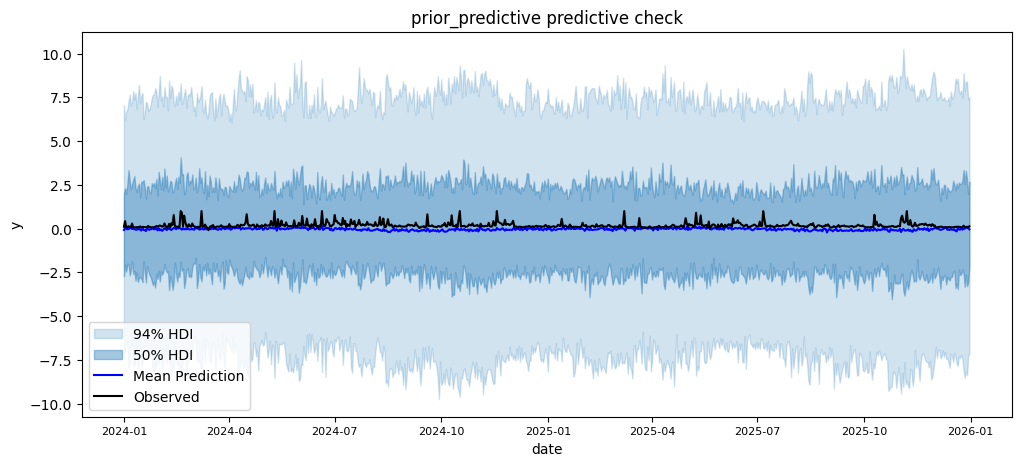

In [ ]:
mmm = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=ADSTOCK_MAP[ADSTOCK_TYPE](l_max=ADSTOCK_L_MAX),
    saturation=SATURATION_MAP[SATURATION_TYPE](),
    model_config=model_config,
    time_varying_intercept=TIME_VARYING_INTERCEPT,
    time_varying_media=TIME_VARYING_MEDIA,
    yearly_seasonality=YEARLY_SEASON,
    sampler_config=SAMPLER_CONFIG,
    dag=CAUSAL_DAG, 
)

mmm_copy = copy.deepcopy(mmm)

# train/test split — 날짜 기반
test_start = pd.Timestamp(TEST_START_DATE)
data_train = variable_selected[variable_selected["date"] < test_start].reset_index(drop=True)
data_test  = variable_selected[variable_selected["date"] >= test_start].reset_index(drop=True)

y = data_train[TARGET_COLUMN].astype(float)
X = data_train[["date"] + channel_columns + control_columns].copy()

print(f"Train: {data_train['date'].min().date()} ~ {data_train['date'].max().date()} ({len(data_train)}일)")
print(f"Test:  {data_test['date'].min().date()} ~ {data_test['date'].max().date()} ({len(data_test)}일)")

mmm.build_model(X, y)

mmm.sample_prior_predictive(X, y, samples=2000)
mmm.plot_prior_predictive(figsize=(12, 5))
plt.xticks(fontsize=8)
save_plot("prior_predictive")
plt.show()

In [ ]:
mmm.fit(
    X=X,
    y=y,
    random_seed=np.random.default_rng(RANDOM_SEED),
)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

## 3. 모델 진단

In [ ]:
priors = mmm.model_config.copy()
if mmm.yearly_seasonality is None:
    priors.pop("gamma_fourier", None)
if mmm.control_columns is None:
    priors.pop("gamma_control", None)
if mmm.time_varying_intercept == True:
    priors.pop("intercept_tvp_config", None)
if mmm.time_varying_media == True:
    priors.pop("media_tvp_config", None)

prior_keys = ["intercept", "y_sigma"] + list(priors.keys())[2:-1]

summary = az.summary(data=mmm.fit_result, var_names=prior_keys)
filtered_summary = summary[
    (summary["ess_bulk"] <= 4000) |
    (summary["ess_tail"] <= 4000) |
    (summary["r_hat"] > 1.01)
]
filtered_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


  Saved: outputs/brand2/result/5_2_10_20260317_175859/trace_plot.png


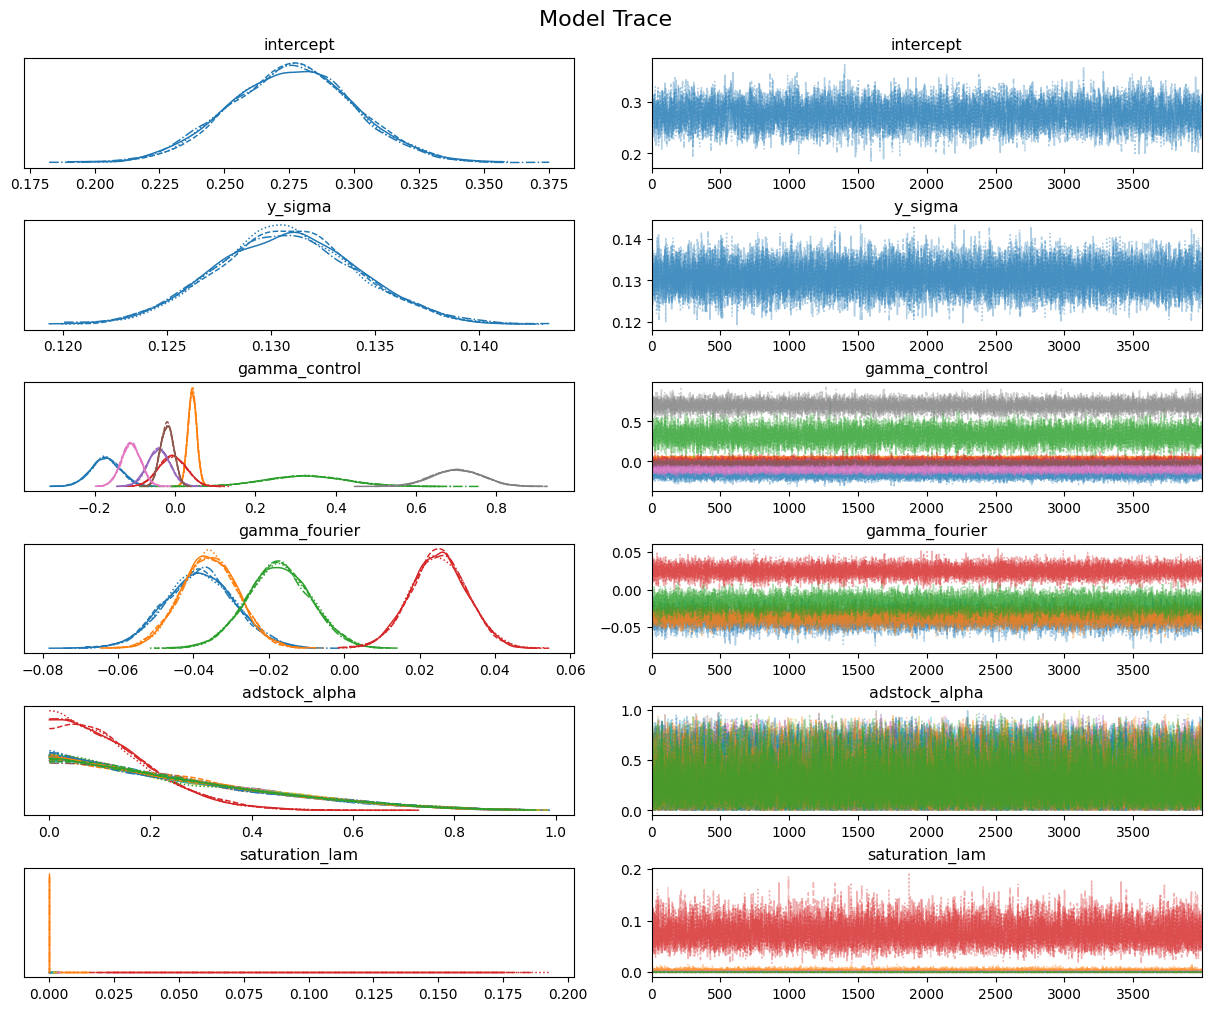

In [ ]:
_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=prior_keys,
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16)
save_plot("trace_plot")

## 4. In-sample 예측 정확도

In [ ]:
mmm.sample_posterior_predictive(X, extend_idata=True, combined=True)

Sampling: [y]


Output()

<xarray.Dataset> Size: 94MB
Dimensions:  (sample: 16000, date: 731)
Coordinates:
  * date     (date) datetime64[ns] 6kB 2024-01-01 2024-01-02 ... 2025-12-31
  * sample   (sample) object 128kB MultiIndex
  * chain    (sample) int64 128kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 128kB 0 1 2 3 4 5 ... 3994 3995 3996 3997 3998 3999
Data variables:
    y        (date, sample) float64 94MB 473.4 1.102e+03 ... -1.909 406.9
Attributes:
    created_at:                 2026-03-17T09:01:39.494595
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.22.0

  Saved: outputs/brand2/result/5_2_10_20260317_175859/posterior_predictive.png


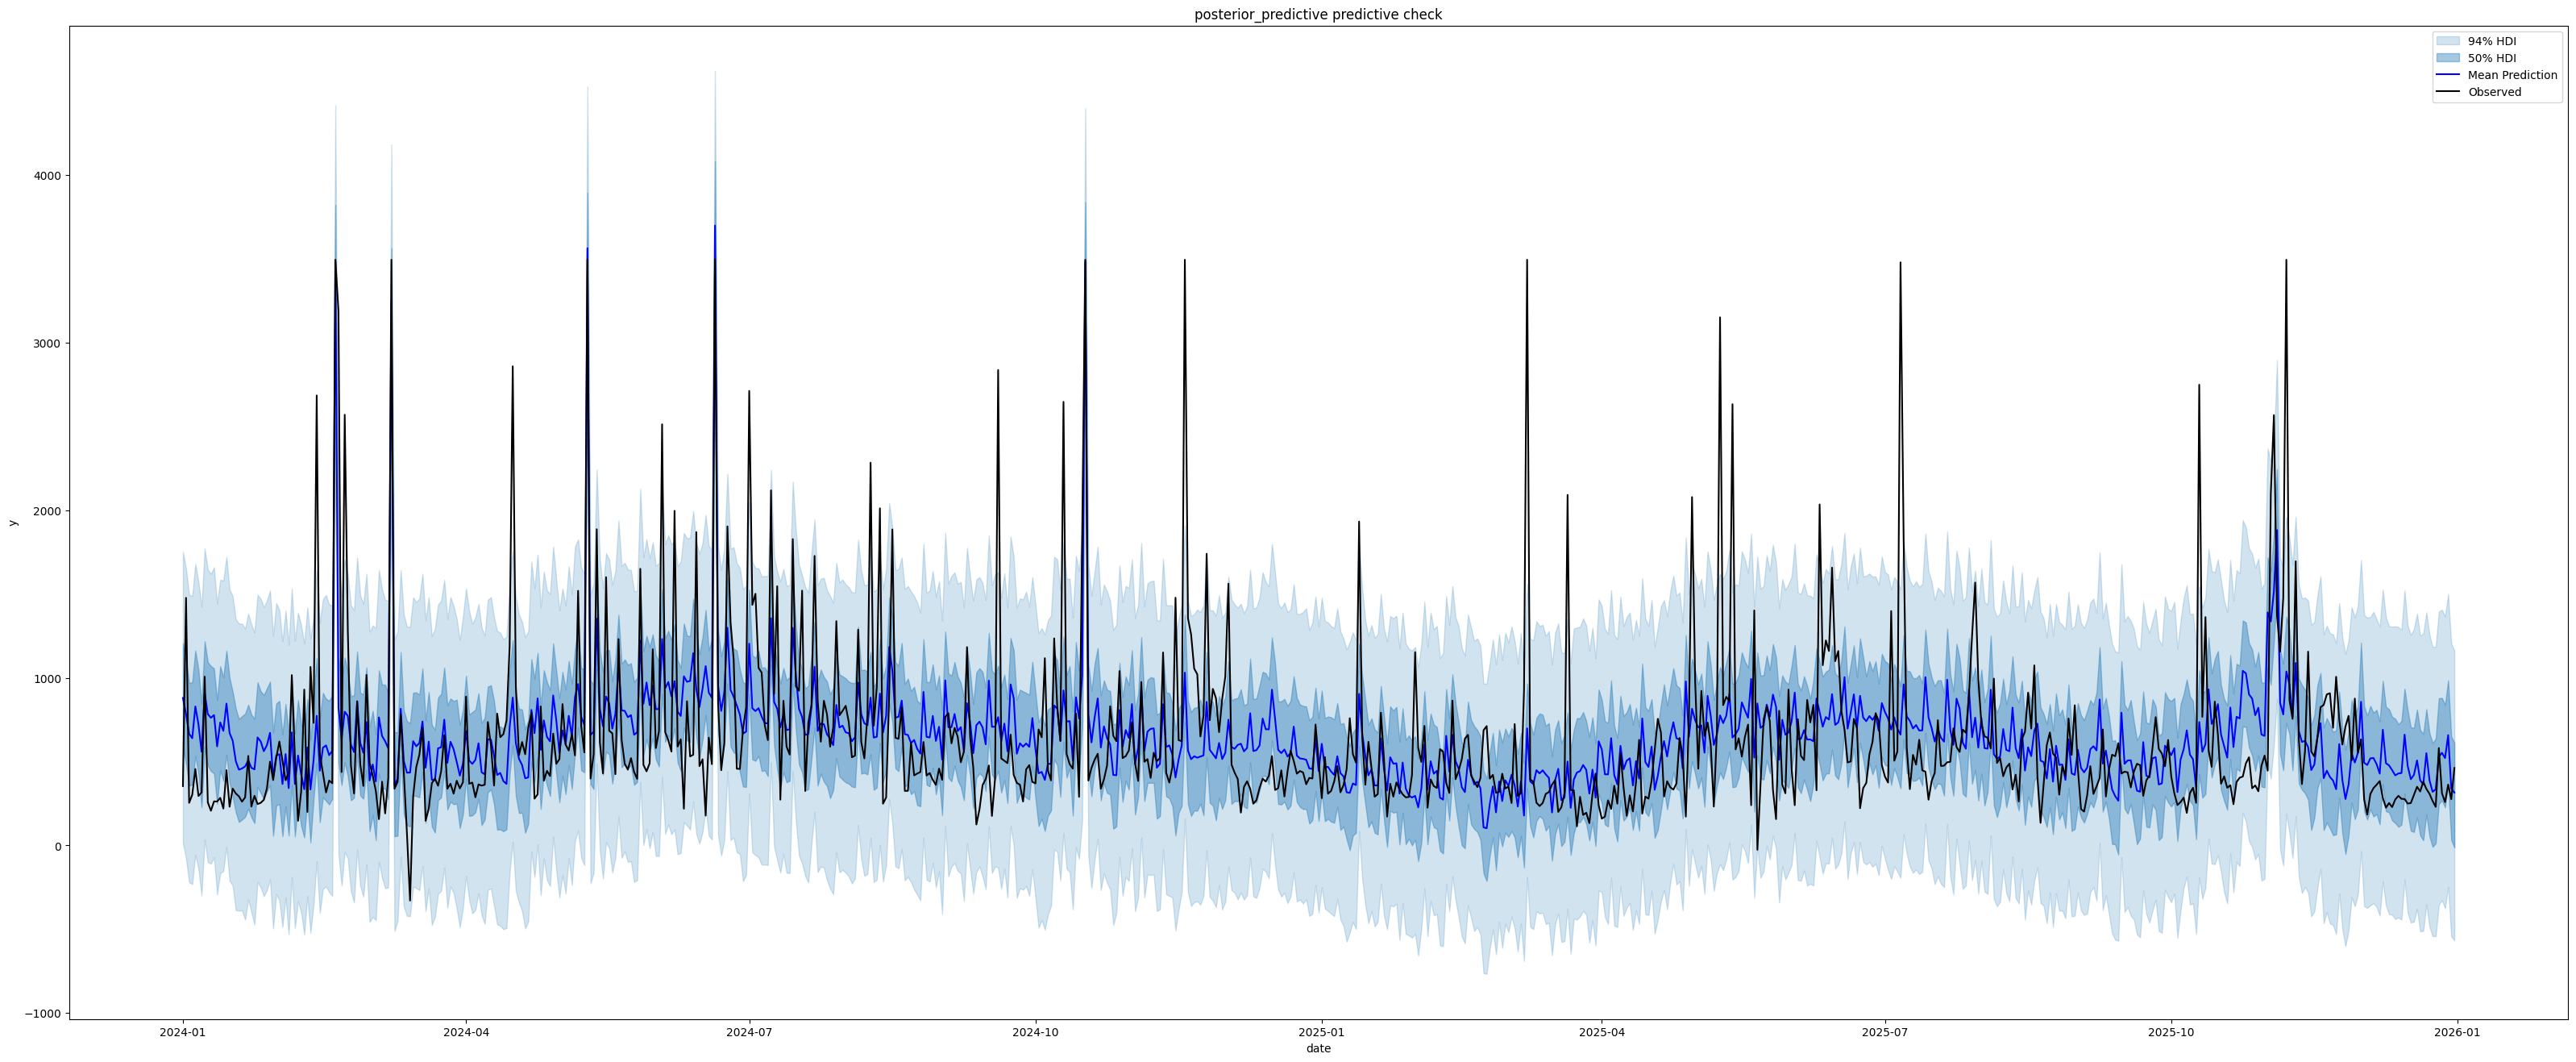

In [ ]:
mmm.plot_posterior_predictive(original_scale=True, figsize=(40, 16))
save_plot("posterior_predictive")

  Saved: outputs/brand2/result/5_2_10_20260317_175859/errors.png


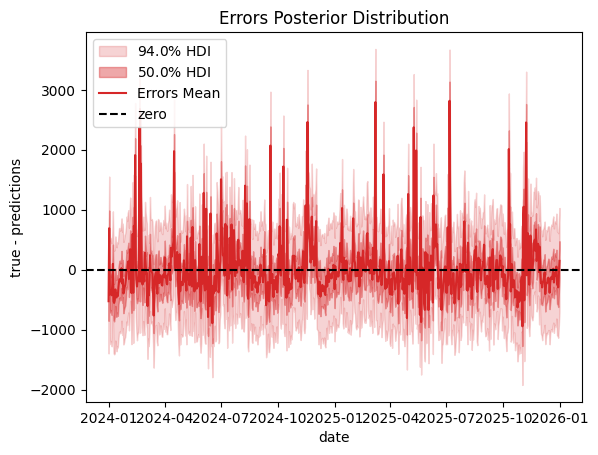

In [ ]:
mmm.plot_errors(original_scale=True)
save_plot("errors")

## 5. Waterfall Decomposition

  Saved: outputs/brand2/result/5_2_10_20260317_175859/waterfall_decomposition.png


<Figure size 2000x1600 with 0 Axes>

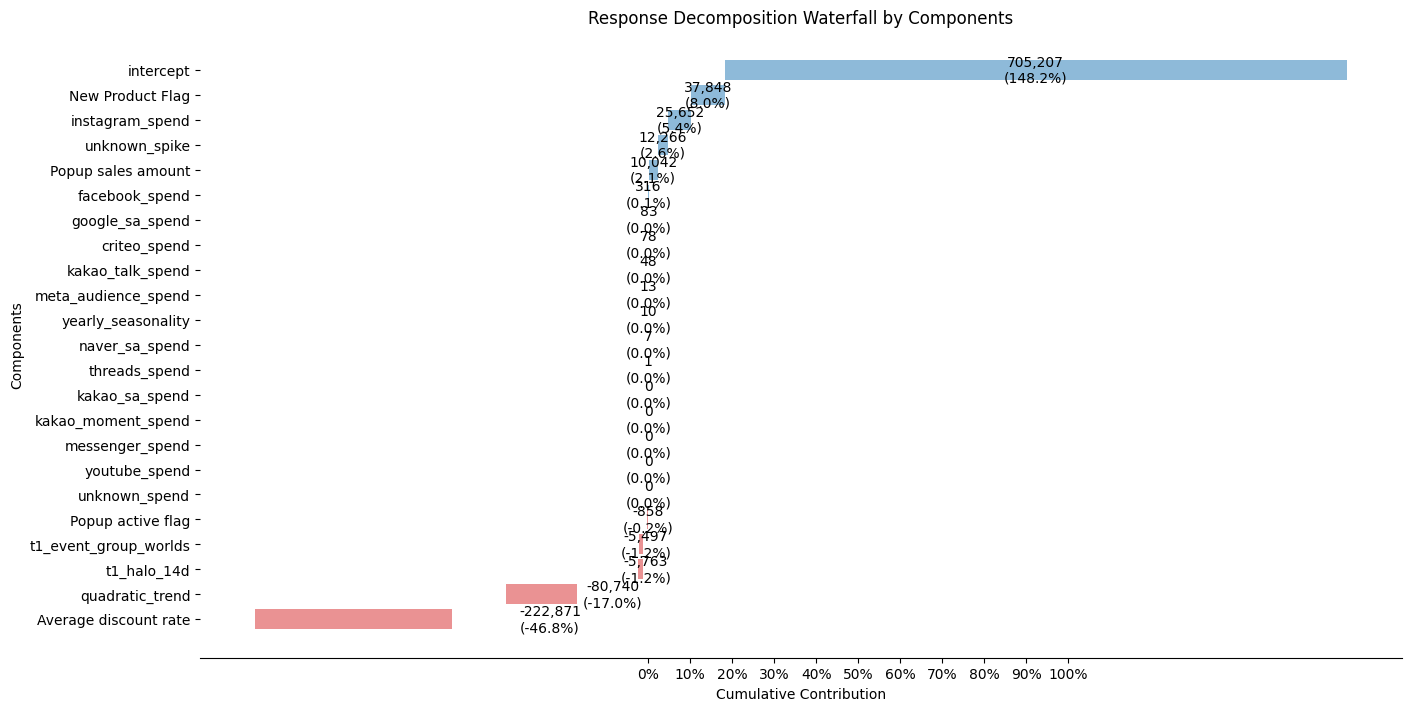

In [ ]:
plt.figure(figsize=(20, 16))
mmm.plot_waterfall_components_decomposition()
save_plot("waterfall_decomposition") 
plt.show()

In [ ]:
# ============================================================
#  DB Catalog 기반 Waterfall 그룹 분류
# ============================================================
import pymysql

_conn = pymysql.connect(
    host="dev-database.czyq0qigimqo.ap-northeast-2.rds.amazonaws.com",
    port=3306, user="admin", password="Shared2024!", database="modeler",
)
_cur = _conn.cursor()
_cur.execute(
    "SELECT variable_en, category FROM 2_variable_catalog WHERE set_id = %s",
    (VARIABLE_SET_ID,),
)
_catalog_map = {row[0]: row[1] for row in _cur.fetchall()}
_conn.close()

# control_columns에서 unknown_spike_* 는 catalog에 없으므로 Base로 취급
seasonality_components = ["yearly_seasonality"] + [c for c in control_columns if "trend" in c]
baseline_control_components = [c for c in control_columns if "trend" not in c and _catalog_map.get(c, "Base") == "Base"]
other_control_components = [c for c in control_columns if "trend" not in c and _catalog_map.get(c) == "Promo"]

print(f"seasonality:    {seasonality_components}")
print(f"baseline (Base): {baseline_control_components}")
print(f"other (Promo):   {other_control_components}")

seasonality:    ['yearly_seasonality', 'quadratic_trend']
baseline (Base): ['Average discount rate', 'unknown_spike']
other (Promo):   ['New Product Flag', 'Popup sales amount', 'Popup active flag', 't1_event_group_worlds', 't1_halo_14d']


  Saved: outputs/brand2/result/5_2_10_20260317_175859/waterfall_grouped.png


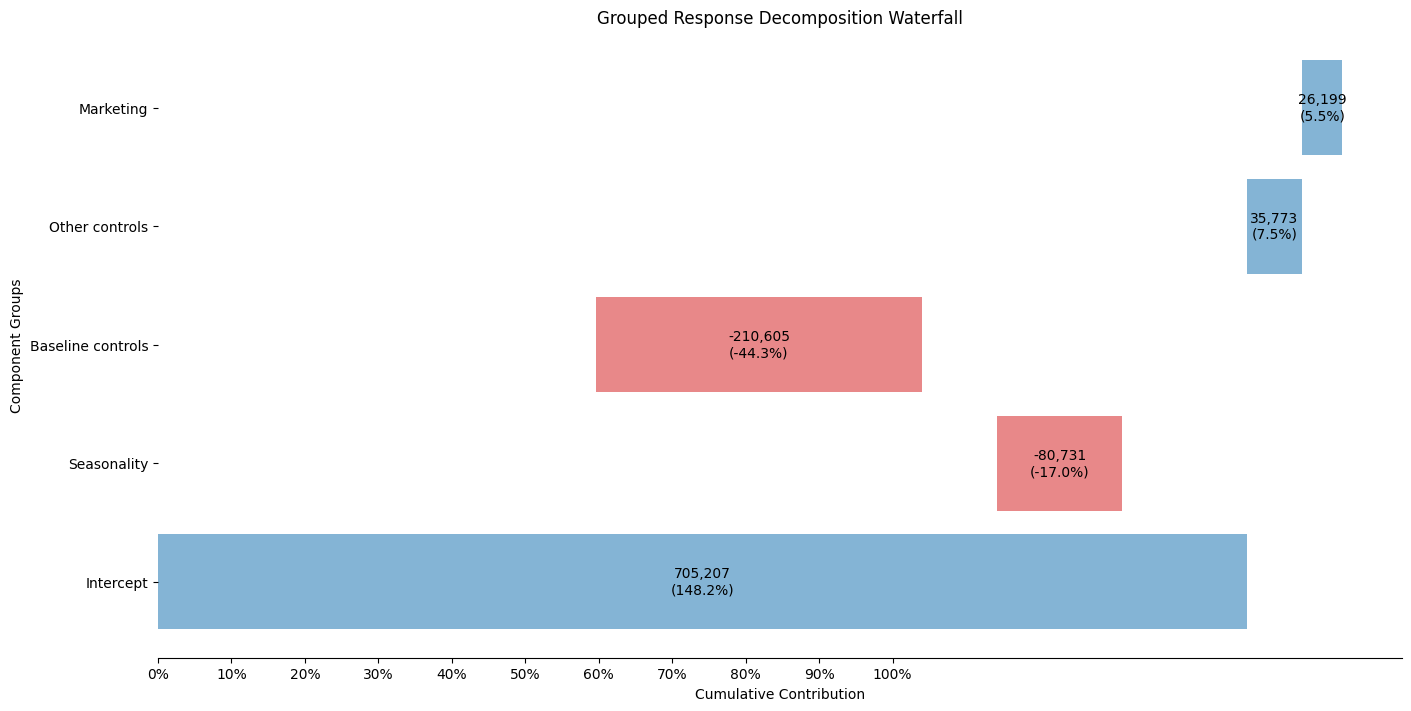

In [ ]:
fig = plot_waterfall_grouped_from_mmm(
    mmm,
    intercept_name="intercept",
    seasonality_components=seasonality_components,
    baseline_control_components=baseline_control_components,
    other_control_components=other_control_components,
    marketing_components=channel_columns,
    original_scale=True,
    intercept_label="Intercept",
    seasonality_label="Seasonality",
    baseline_control_label="Baseline controls",
    other_control_label="Other controls",
    marketing_label="Marketing",
)
save_plot("waterfall_grouped")

## 6. Train/Test 평가

In [ ]:
is_df, oos_df, metrics, raw = evaluate_mmm_train_test_ppc(
    mmm=mmm,
    data_train=data_train,
    data_test=data_test,
    target_col=TARGET_COLUMN,
    date_col="date",
    include_last_observations_oos=True,
)

y_scale_train = is_df["y_true"].mean()
y_scale_test  = oos_df["y_true"].mean()

metrics_df, score_df, display_df = prettify_metrics(
    metrics,
    y_scale_train=y_scale_train,
    y_scale_test=y_scale_test,
)

# Add nCRPS (normalized CRPS = CRPS / mean(y_true))
ncrps_train = float(display_df.loc[0, "CRPS"]) / y_scale_train
ncrps_test  = float(display_df.loc[1, "CRPS"]) / y_scale_test
display_df["nCRPS"] = [f"{ncrps_train:.4f}", f"{ncrps_test:.4f}"]

display_df

Sampling: [y]


Output()

Sampling: [y]


Output()

,sample,R2,MAPE,CRPS,nCRPS
0,train,0.330,51.20%,224.7144,0.3453
1,test,-1.238,61.97%,197.4072,0.4848


In [ ]:
# ============================================================
#  주간(Weekly) 합계 기준 Train/Test 평가
# ============================================================
from properscoring import crps_ensemble
from utils import r2_score, mean_absolute_percentage_error

def weekly_metrics(pred_df, ppc_xr, output_var="y"):
    """일별 pred_df + posterior samples → 주간 합계 R2/MAPE/CRPS/nCRPS"""
    df = pred_df.copy()
    df["week"] = df["date"].dt.isocalendar().week.astype(int)
    df["year"] = df["date"].dt.isocalendar().year.astype(int)

    # 주간 합계 (y_true, y_pred)
    weekly = df.groupby(["year", "week"]).agg(
        y_true=("y_true", "sum"),
        y_pred=("y_pred", "sum"),
        n_days=("y_true", "count"),
    ).reset_index()
    # 불완전한 주 제거 (7일 미만)
    weekly = weekly[weekly["n_days"] == 7].reset_index(drop=True)

    w_r2 = r2_score(weekly["y_true"].values, weekly["y_pred"].values)
    w_mape = mean_absolute_percentage_error(weekly["y_true"].values, weekly["y_pred"].values)

    # 주간 CRPS: posterior samples도 주간 합산
    n_obs = len(pred_df)
    samples_2d = ppc_xr[output_var].values.reshape(-1, n_obs).T  # (obs, samples)

    df["_idx"] = range(n_obs)
    idx_groups = df.groupby(["year", "week"])["_idx"].apply(list).reset_index()
    idx_groups.columns = ["year", "week", "indices"]
    idx_groups = idx_groups.merge(weekly[["year", "week"]], on=["year", "week"])

    weekly_samples = np.array([samples_2d[idxs].sum(axis=0) for idxs in idx_groups["indices"]])
    weekly_true = weekly["y_true"].values
    w_crps = float(np.mean(crps_ensemble(weekly_true, weekly_samples)))
    w_ncrps = w_crps / weekly_true.mean()

    return w_r2, w_mape, w_crps, w_ncrps, len(weekly)

# --- Train 주간 ---
is_ppc = mmm.sample_posterior_predictive(data_train, extend_idata=False, combined=False)
tr_r2, tr_mape, tr_crps, tr_ncrps, tr_weeks = weekly_metrics(is_df, is_ppc)

# --- Test 주간 ---
oos_ppc = mmm.sample_posterior_predictive(data_test, extend_idata=False, combined=False,
                                          include_last_observations=True)
te_r2, te_mape, te_crps, te_ncrps, te_weeks = weekly_metrics(oos_df, oos_ppc)

weekly_display_df = pd.DataFrame([
    {"sample": f"train ({tr_weeks}w)", "R2": f"{tr_r2:.3f}", "MAPE": f"{tr_mape:.2f}%",
     "CRPS": f"{tr_crps:.2f}", "nCRPS": f"{tr_ncrps:.4f}"},
    {"sample": f"test ({te_weeks}w)", "R2": f"{te_r2:.3f}", "MAPE": f"{te_mape:.2f}%",
     "CRPS": f"{te_crps:.2f}", "nCRPS": f"{te_ncrps:.4f}"},
])

print("=== Weekly Aggregate Metrics ===")
weekly_display_df

Sampling: [y]


Output()

Sampling: [y]


Output()

=== Weekly Aggregate Metrics ===


,sample,R2,MAPE,CRPS,nCRPS
0,train (104w),0.385,31.58%,904.28,0.1981
1,test (7w),-37.278,61.83%,1058.17,0.4303


Sampling: [y]


Output()

  Saved: outputs/brand2/result/5_2_10_20260317_175859/prediction_comparison.png


/Users/ansaejin/Desktop/renewal/module/utils.py:986: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  X_out_of_sample['date'].dt.to_pydatetime(),


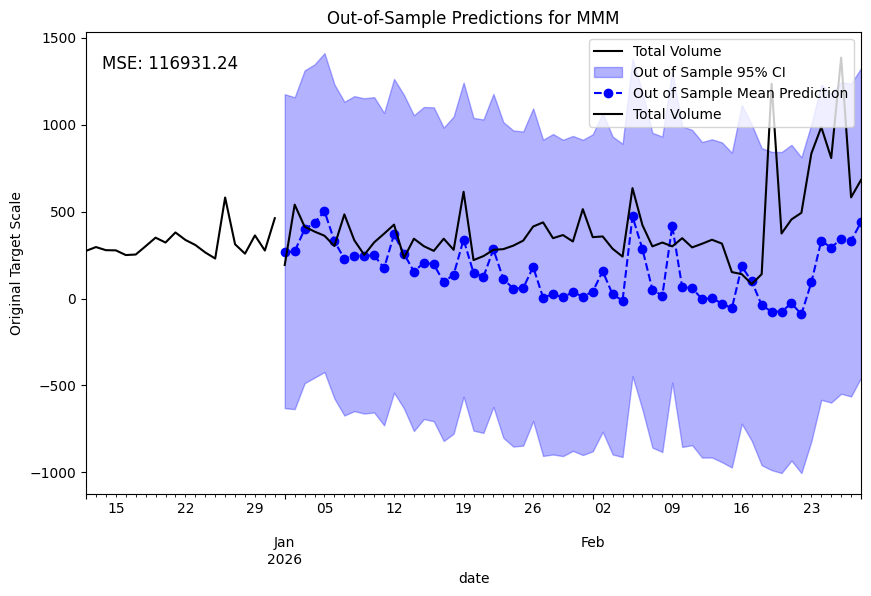

In [ ]:
plot_prediction_comparison(
    data_train,
    data_test,
    mmm.sample_posterior_predictive(data_test, extend_idata=False),
    target=TARGET_COLUMN,
)
save_plot("prediction_comparison")
plt.show()

## 7. 포화 곡선 / Granger Test

In [ ]:
# --- Granger Test (주석 처리: S3 업로드 대상 아님) ---
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=FutureWarning, message=".*verbose is deprecated.*")
#     results = granger_best_lag_many(
#         variable_selected,
#         x_cols=channel_columns,
#         y_col=target_column,
#         max_lag=12,
#         criterion="first_sig",
#         alpha=0.05,
#     )
# results

In [ ]:
# --- Knee Point (주석 처리: S3 업로드 대상 아님) ---
# df_knee = get_channel_contribution_knee_df(
#     mmm, start=0, stop=1.5, num=12, absolute_xrange=True, hdi_prob=0.94
# )
# df_knee.sort_values(["knee_share", "knee_contribution_mean"], ascending=[True, False])

  Saved: outputs/brand2/result/5_2_10_20260317_175859/channel_contributions_grid.png


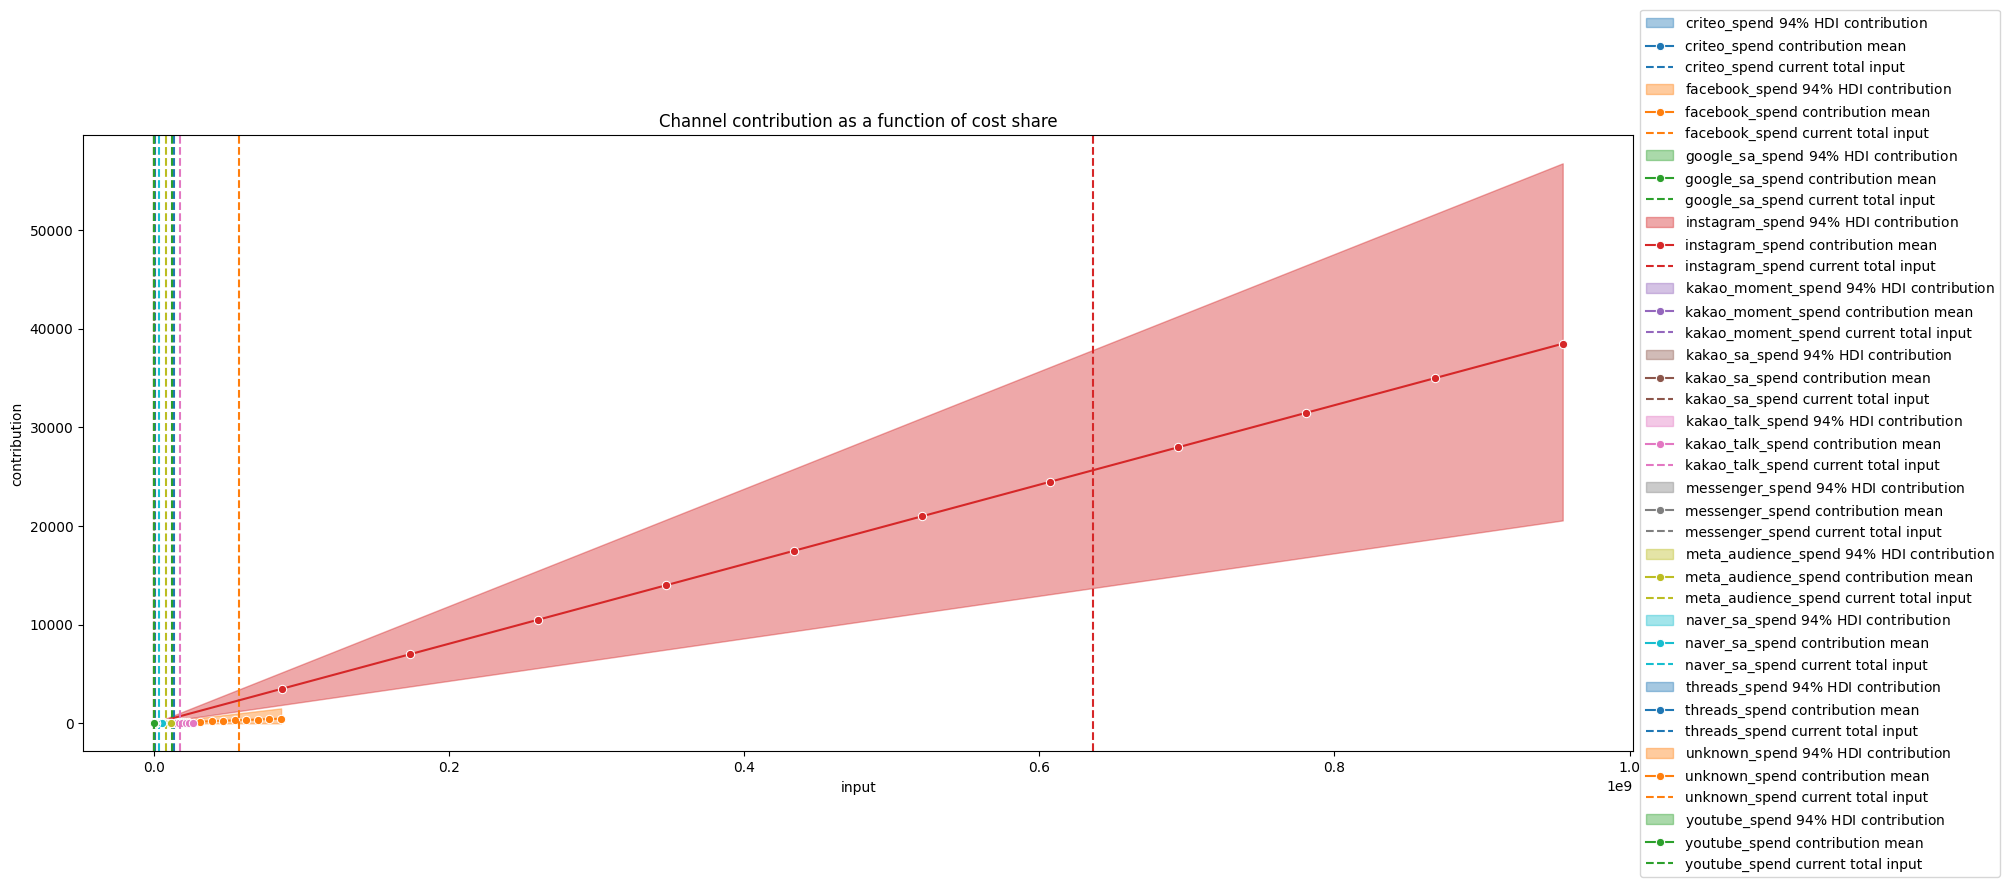

In [ ]:
mmm.plot_channel_contributions_grid(
    start=0, stop=1.5, num=12, absolute_xrange=True, figsize=(20, 8))
save_plot("channel_contributions_grid")

## 8. Component Contributions

  Saved: outputs/brand2/result/5_2_10_20260317_175859/components_contributions.png


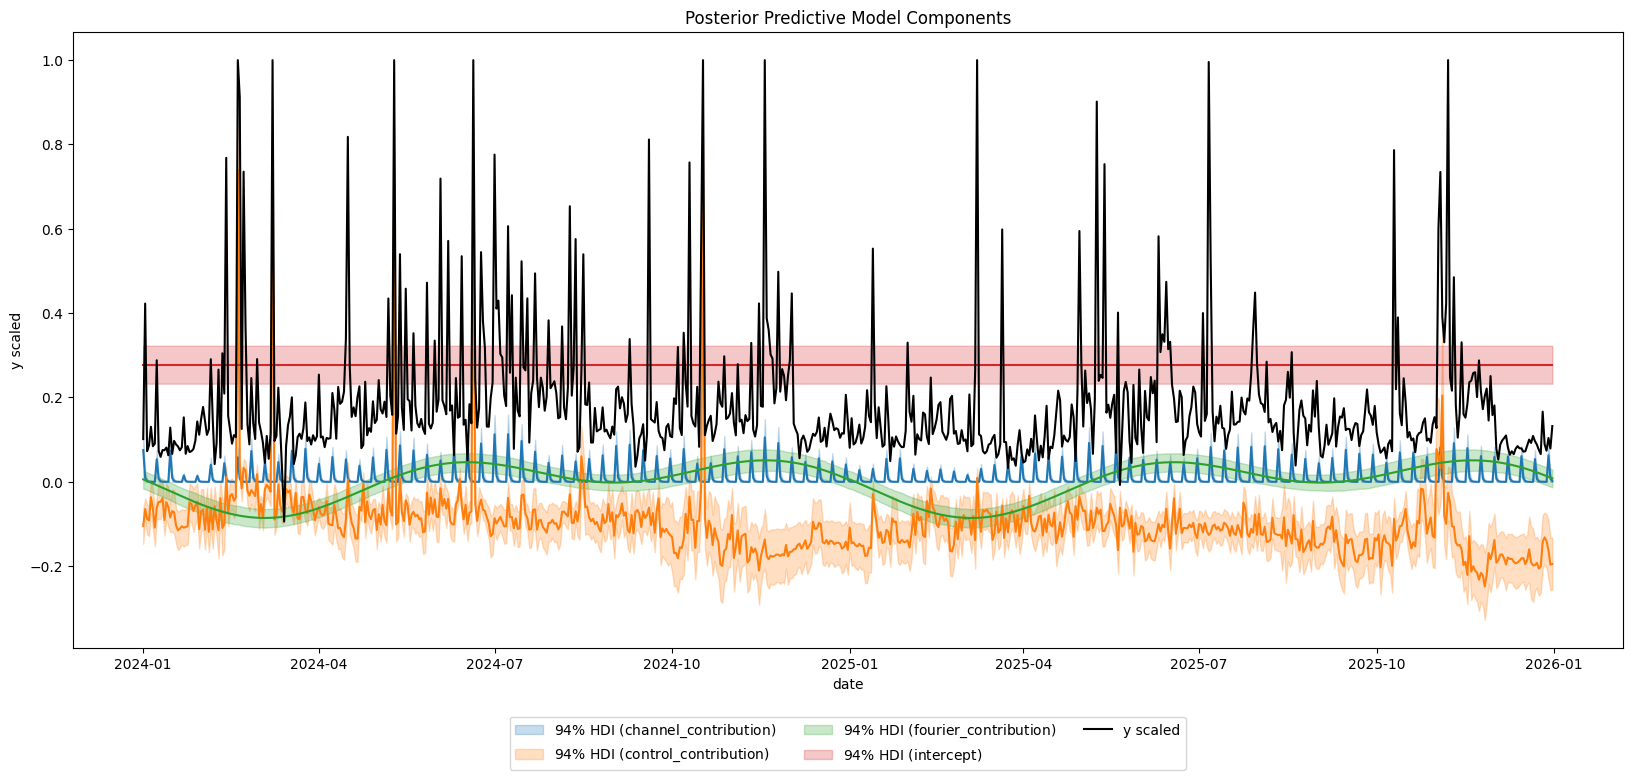

In [ ]:
mmm.plot_components_contributions(figsize=(20, 8))
save_plot("components_contributions")
plt.show()

## 9. Holdout Test

In [ ]:
# holdout_list = [4, 8, 12]
#
# multi_result = evaluate_mmm_with_multi_holdout(
#     mmm=mmm_copy,
#     data=variable_selected,
#     target=TARGET_COLUMN,
#     date_col="date",
#     holdout_list=holdout_list,
# )
#
# multi_result["metrics_table"]

In [ ]:
# res = evaluate_mmm_weekly_and_aggregate_multi_holdout(
#     mmm=mmm_copy,
#     data=variable_selected,
#     target=TARGET_COLUMN,
#     holdout_weeks_list=(4, 13, 26, 52),
#     weekly_eval_weeks=6,
#     rolling=False,
#     store_pred_dfs=False,
#     max_crps_draws=500,
# )
# summary = res["summary"]
# summary

## 10. S3 업로드 & action-modeler 연동
- 모든 plot을 PNG로 저장 후 S3에 업로드
- 주요 지표(metrics)를 JSON으로 S3에 업로드
- action-modeler 사이트에서 결과를 확인할 수 있도록 구조화된 경로로 저장

In [ ]:
# ============================================================
# S3 업로드 경로 설정
# ============================================================
s3_result      = f"{S3_PREFIX}/{BRAND_ID}/result/{RESULT_DIR_NAME}"
s3_config_set  = f"{S3_PREFIX}/{BRAND_ID}/config_set"

print(f"Local output:   {local_dir}")
print(f"S3 result:      s3://{S3_BUCKET}/{s3_result}/")
print(f"S3 config_set:  s3://{S3_BUCKET}/{s3_config_set}/")

Local output:   outputs/brand2/result/5_2_10_20260317_175859
S3 result:      s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/
S3 config_set:  s3://action-kpi-bucket/model_result/brand2/config_set/


In [ ]:
# ============================================================
# 지표 + 모델 설정 JSON 저장
# ============================================================
metrics_output = {
    "brand_id": BRAND_ID,
    "variable_set_id": VARIABLE_SET_ID,
    "group_id": GROUP_ID,
    "config_set_id": CONFIG_SET_ID,
    "run_id": RUN_ID,
    "note": NOTE,

    # --- 모델 설정 ---
    "model_settings": {
        "date_column": mmm.date_column,
        "channel_columns": list(mmm.channel_columns),
        "control_columns": list(mmm.control_columns) if mmm.control_columns is not None else [],
        "target_column": TARGET_COLUMN,
        "adstock": {
            "type": type(mmm.adstock).__name__,
            "l_max": mmm.adstock.l_max,
        },
        "saturation": {
            "type": type(mmm.saturation).__name__,
        },
        "time_varying_intercept": mmm.time_varying_intercept,
        "time_varying_media": mmm.time_varying_media,
        "yearly_seasonality": mmm.yearly_seasonality,
        "dag": getattr(mmm, "dag", None),
        "sampler_config": mmm.sampler_config,
        "model_config": {
            k: str(v) for k, v in mmm.model_config.items()
        },
    },

    # --- 데이터 정보 ---
    "data_info": {
        "var_names": var_names,
        "n_total": len(variable_selected),
        "n_train": len(data_train),
        "n_test": len(data_test),
        "split_ratio": round(len(data_train) / len(variable_selected), 4),
        "test_start_date": TEST_START_DATE,
        "date_range_train": [str(data_train["date"].min()), str(data_train["date"].max())],
        "date_range_test": [str(data_test["date"].min()), str(data_test["date"].max())],
    },

    # --- 평가 지표 (일별) ---
    "train_test_metrics": display_df.to_dict(orient="records"),

    # --- 평가 지표 (주간 합계) ---
    "weekly_metrics": weekly_display_df.to_dict(orient="records"),
}

metrics_path = local_dir / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_output, f, ensure_ascii=False, indent=2, default=str)

print(f"Metrics saved: {metrics_path}")

Metrics saved: outputs/brand2/result/5_2_10_20260317_175859/metrics.json


In [ ]:
# ============================================================
# S3 업로드
# ============================================================
uploaded = []

# --- 1) result 업로드 (metrics.json + plot PNGs) ---
print("=== Result 업로드 ===")
for file_path in local_dir.iterdir():
    s3_key = f"{s3_result}/{file_path.name}"
    content_type = "image/png" if file_path.suffix == ".png" else "application/json"
    s3.upload_file(
        str(file_path), S3_BUCKET, s3_key,
        ExtraArgs={"ContentType": content_type},
    )
    uploaded.append(s3_key)
    print(f"  s3://{S3_BUCKET}/{s3_key}")

# --- 2) config_set 업로드 ---
print("\n=== Config Set ===")
config_key = f"{s3_config_set}/config_set_{CONFIG_SET_ID}.json"

if CONFIG_FROM_S3:
    # S3에서 불러온 config → 이미 존재하므로 재업로드 안 함
    print(f"  (S3 모드) 기존 config 사용, 업로드 스킵: {config_key}")
else:
    # Manual config → 같은 ID가 이미 있는지 확인
    config_exists = False
    try:
        s3.head_object(Bucket=S3_BUCKET, Key=config_key)
        config_exists = True
    except s3.exceptions.ClientError:
        pass

    if config_exists:
        print(f"  config_set_{CONFIG_SET_ID}.json 이 이미 S3에 존재합니다!")
        print(f"  덮어쓰지 않습니다. CONFIG_SET_ID를 변경해주세요.")
    else:
        config_set_data = {
            "config_set_id": CONFIG_SET_ID,
            "adstock": {
                "type": type(mmm.adstock).__name__,
                "l_max": mmm.adstock.l_max,
            },
            "saturation": {
                "type": type(mmm.saturation).__name__,
            },
            "yearly_seasonality": YEARLY_SEASON,
            "time_varying_intercept": TIME_VARYING_INTERCEPT,
            "time_varying_media": TIME_VARYING_MEDIA,
            "sampler_config": SAMPLER_CONFIG,
            "train_ratio": round(len(data_train) / len(variable_selected), 4),
            "random_seed": RANDOM_SEED,
            "model_config": {k: str(v) for k, v in mmm.model_config.items()},
        }
        s3.put_object(
            Bucket=S3_BUCKET,
            Key=config_key,
            Body=json.dumps(config_set_data, ensure_ascii=False, indent=2, default=str),
            ContentType="application/json",
        )
        uploaded.append(config_key)
        print(f"  새 config 업로드: s3://{S3_BUCKET}/{config_key}")

print(f"\n총 {len(uploaded)}개 파일 업로드 완료.")

=== Result 업로드 ===
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/metrics.json
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/errors.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/waterfall_grouped.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/trace_plot.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/prior_predictive.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/components_contributions.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/posterior_predictive.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/channel_contributions_grid.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/prediction_comparison.png
  s3://action-kpi-bucket/model_result/brand2/result/5_2_10_20260317_175859/waterfall_decomposition.png

=== Confi